# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [1]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [2]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [3]:
print(data[0],type(data[0]))

0.25 <class 'numpy.float64'>


In [4]:
print(data[2:],type(data[2:]))

2    0.75
3    1.00
dtype: float64 <class 'pandas.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [5]:
print(data.values,type(data.values))

[0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [7]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=4, step=1) <class 'pandas.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [8]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])
print(data)

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64


In [10]:
print(data['c'])

0.75


In [12]:
print(data['a'])

0.25


In [17]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[1, 3, 4, 2])
print(data)

1    0.25
3    0.50
4    0.75
2    1.00
dtype: float64


In [18]:
print(data[2])


1.0


In [20]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[10,9,8,7])
print(data)

10    0.25
9     0.50
8     0.75
7     1.00
dtype: float64


In [21]:
print(data[8])


0.75


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [22]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.Series'>


In [23]:
population['California']

np.int64(38332521)

In [25]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [26]:
population['Texas':'Florida']

Texas       26448193
New York    19651127
Florida     19552860
dtype: int64

In [29]:
population[["Texas", "Florida"]]

Texas      26448193
Florida    19552860
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [31]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})

In [34]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [ ]:
states

DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [35]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='str')
Index(['Population', 'Area'], dtype='str')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [37]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.Series'>


In [38]:
print(states['Population'],type(states['Population']))

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
Name: Population, dtype: int64 <class 'pandas.Series'>


In [40]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'California'


In [41]:
try:
    print(states['Saad'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'Saad'


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [42]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [43]:
A = np.random.randn(5,3)
print(A,type(A))
dfA = pd.DataFrame(A)
dfA

[[ 0.28049522 -0.12249456 -0.14444043]
 [-0.04337557  1.07774179 -0.76897488]
 [ 0.46668405 -2.03208297 -1.56643267]
 [ 0.33227162 -0.56527969 -1.56614082]
 [ 1.19846725  0.26226559  0.14321207]] <class 'numpy.ndarray'>


,0,1,2
0,0.280495,-0.122495,-0.144440
1,-0.043376,1.077742,-0.768975
2,0.466684,-2.032083,-1.566433
3,0.332272,-0.565280,-1.566141
4,1.198467,0.262266,0.143212


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [44]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [45]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [53]:
# bash command to see the first 4 lines of the file
df = pd.read_csv(r"D:\Saad Maqbool\Week 2\president_heights.csv")
df.head(4)

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163


In [9]:
data = pd.read_csv(r"D:\Saad Maqbool\Week 2\president_heights.csv")
data

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


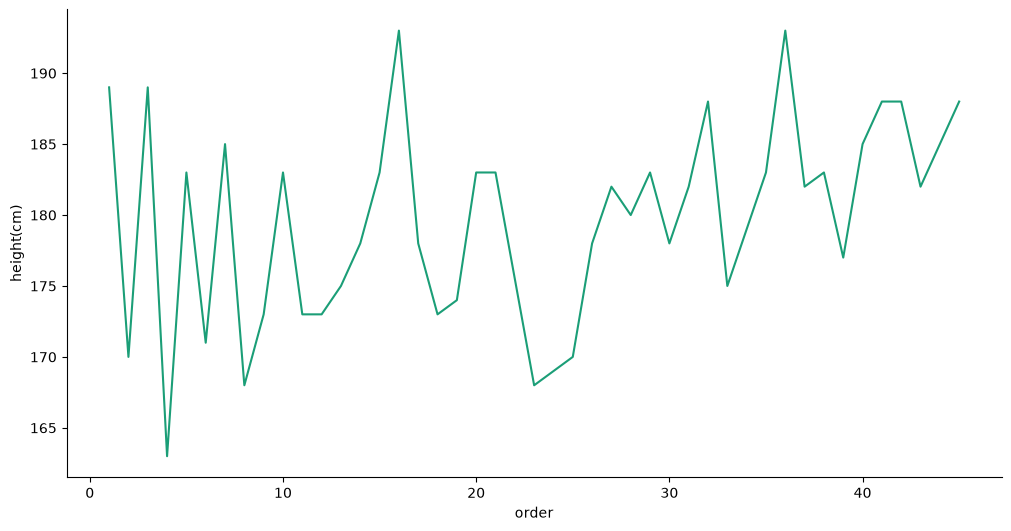

In [4]:
# @title order vs height(cm)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['order']
  ys = series['height(cm)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('order', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('order')
_ = plt.ylabel('height(cm)')

### Names and Values

Notice there can be missing values in DataFrames.

In [5]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [12]:
import pandas as pd

# Create dfA
dfA = pd.DataFrame({
    'col1': [1, 2, 3, 4, 5],
    'col2': [4, 5, 6, 7, 8],
    'col3': [7, 8, 9, 10, 11]
})

# Now rename columns and index
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)]
dfA

,a,b,c
1,1,4,7
4,2,5,8
9,3,6,9
16,4,7,10
25,5,8,11


## Indexing




In [13]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


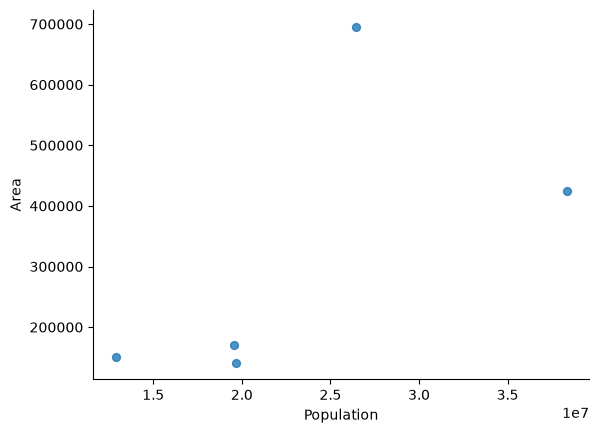

In [14]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

You may access columns directly with names, *then* you can access individuals with their index.

In [15]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [16]:
states['Area']['Texas']

np.int64(695662)

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [17]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [18]:
states.iloc[:2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [19]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [20]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

In [23]:
#Series
import pandas as pd
s = pd.Series([10, 20, 30, 40, 50])
print(s[2])
print(s.dtype)

30
int64


In [33]:
#DataFrames
import pandas as pd

df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35]
})
df

,Name,Age
0,Alice,25
1,Bob,30
2,Charlie,35


In [27]:
print(df['Age'])

0    25
1    30
2    35
Name: Age, dtype: int64


In [28]:
print(df.shape)

(3, 2)


In [34]:
#Indexing
df.set_index('Name', inplace=True)
df

,Age
Name,
Alice,25
Bob,30
Charlie,35


In [35]:
print(df.loc['Bob'])

Age    30
Name: Bob, dtype: int64


In [36]:
print(df.iloc[0, 0])

25


In [38]:
#File I/O
df = pd.read_csv(r"D:\Saad Maqbool\Week 2\president_heights.csv")
print("Average height:", df['height(cm)'].mean())


Average height: 179.93023255813952


In [39]:
tallest = df[df['height(cm)'] == df['height(cm)'].max()]
print("Tallest president:", tallest['name'].values[0])

Tallest president: Abraham Lincoln


In [41]:
tallest = df[df['height(cm)'] == df['height(cm)'].max()]
print("Tallest president:", tallest[['name', 'height(cm)']].values[0])

Tallest president: ['Abraham Lincoln' 193]


In [43]:
#ADVANCED
import numpy as np
df = pd.DataFrame(np.random.randint(1, 100, size=(5, 3)), columns=['A', 'B', 'C'])
df

,A,B,C
0,88,69,56
1,22,46,34
2,4,40,80
3,18,20,58
4,47,59,33


In [44]:
print("Mean of each column:")
print(df.mean())
print("\n")

Mean of each column:
A    35.8
B    46.8
C    52.2
dtype: float64




In [47]:
df['D'] = df['A'] + df['B']
df

,A,B,C,D
0,88,69,56,157
1,22,46,34,68
2,4,40,80,44
3,18,20,58,38
4,47,59,33,106


In [52]:
df_sorted = df.sort_values('D', ascending=False)
df['sorted'] = df_sorted['D'].values
df

,A,B,C,D,sorted
0,88,69,56,157,157
1,22,46,34,68,106
2,4,40,80,44,68
3,18,20,58,38,44
4,47,59,33,106,38


In [53]:
print("DataFrame sorted by D (descending):")
print(df_sorted)

DataFrame sorted by D (descending):
    A   B   C    D
0  88  69  56  157
4  47  59  33  106
1  22  46  34   68
2   4  40  80   44
3  18  20  58   38
